In [146]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage.filters import gaussian_filter1d
import itertools
import math
import copy
import ptitprince as pt

PYTHON_PATH = "/Users/rb4174/Library/CloudStorage/OneDrive-PrincetonUniversity/Projects/brain_dev_primates/altricial_brain_vocal_learning"


/var/folders/ys/4vmt6skn47v69q7dptm_7p3m0000gp/T/ipykernel_53922/2947908779.py:5: DeprecationWarning: Please use `gaussian_filter1d` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter1d


In [147]:
# Define the growth functions
def normalized_growth_Gompertz(t, k, t0, L):
    """
    Gompertz growth function.
    A normalized growth function that starts at 0 and ends at L (maximum value).
    t: time
    k: growth rate
    t0: midpoint of the growth
    L: maximum value (carrying capacity)
    """
    return L * np.exp(-np.exp(-k * (t - t0)))

def normalized_growth_rate_Gompertz(t, k, t0, L):
    """
    Gompertz growth rate function.
    The derivative of the normalized growth function.
    t: time
    k: growth rate
    t0: midpoint of the growth
    L: maximum value (carrying capacity)
    """
    #gompertz = normalized_growth_Gompertz(t, k, t0, L)
    #return L * k * gompertz * np.exp(-k * (t - t0))
    return L * np.exp(-np.exp(-k * (t - t0))) * np.exp(-k * (t - t0)) * k



# def normalized_growth_logistic(t, k, t0, L):
#     """
#     A normalized growth function that starts at 0 and ends at L (maximum value).
#     t: time
#     k: growth rate
#     t0: midpoint of the growth
#     L: maximum value (carrying capacity)
#     """
#     return L / (1 + np.exp(-k * (t - t0)))


# def normalized_growth_rate_logistic(t, k, t0, L):
#     """
#     The derivative of the normalized growth function.
#     t: time
#     k: growth rate
#     t0: midpoint of the growth
#     L: maximum value (carrying capacity)
#     """
#     growth = normalized_growth_logistic(t, k, t0, L)
#     return k * growth * (1 - growth / L)

In [196]:
# Choose the growth function to use
normalized_growth = normalized_growth_Gompertz  # Use Gompertz growth function for consistency
normalized_growth_rate = normalized_growth_rate_Gompertz  # Use Gompertz growth rate function for consistency

# Define parameters for the growth function
t_birth_values = [2.2,3.2]  # Different birth times
L_k_t0_combinations = [(5, 4, 2,"lightgrey"), (100, 1, 3,"black")]  # Combinations of L, k, and t0

# Generate time points
t = np.linspace(0, 10, 100)


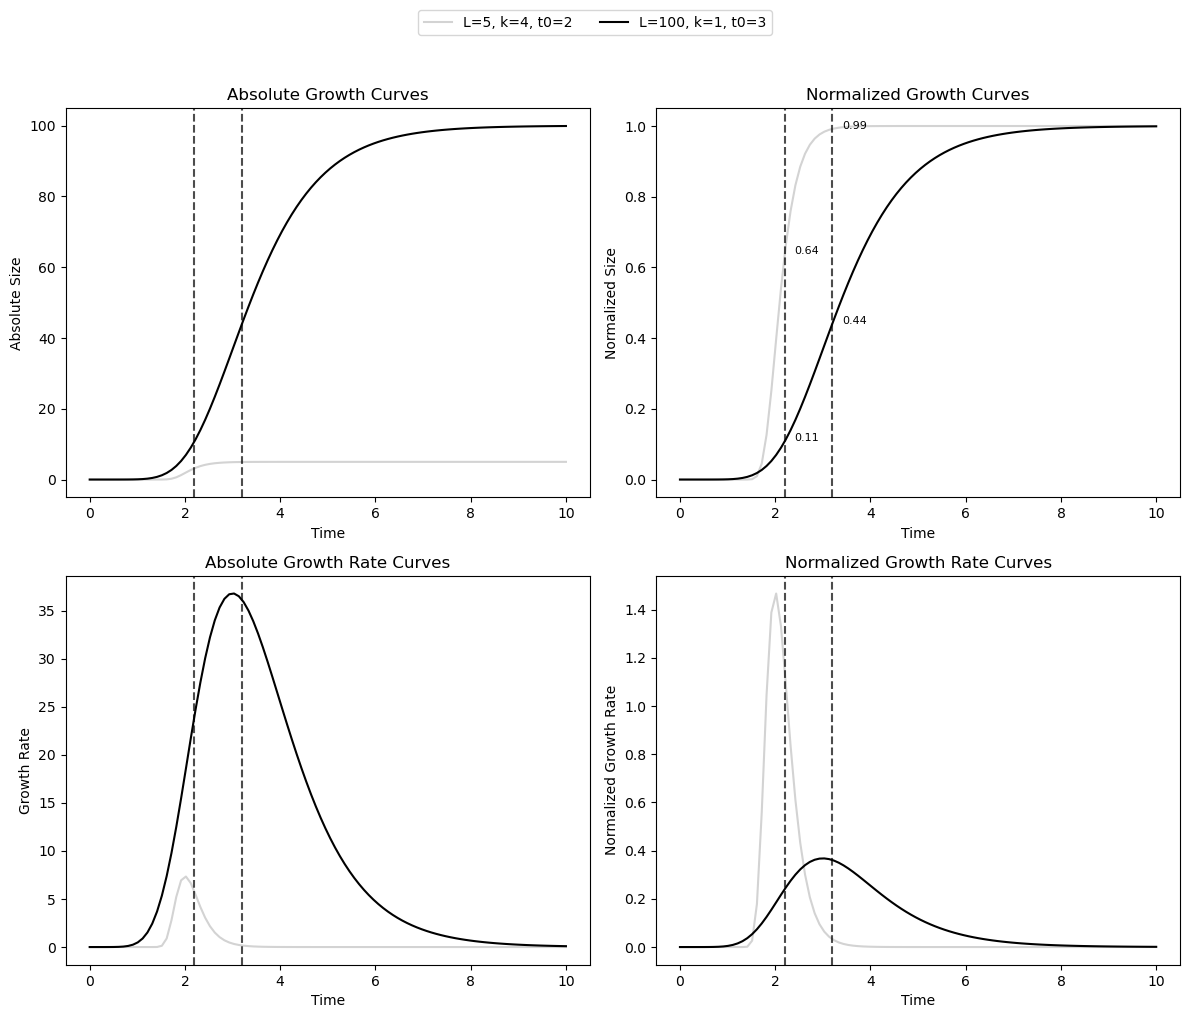

In [197]:
#Plot
# Create a figure with 4 subplots
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

# Plot the absolute growth curves (left column, top)
for L, k, t0, color in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = normalized_growth(t, k, t0, L)
    ax[0, 0].plot(t, y, color = color, label=f'L={L}, k={k}, t0={t0}')

# Add vertical lines for different birth times (absolute growth curves)
for t_birth in t_birth_values:
    ax[0, 0].axvline(x=t_birth, color='black', linestyle='--', alpha=0.7)

# Plot the absolute growth rate curves (left column, bottom)
for L, k, t0, color in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = normalized_growth_rate(t, k, t0, L)
    ax[1, 0].plot(t, y, color = color,label=f'L={L}, k={k}, t0={t0}')

# Add vertical lines for different birth times (absolute growth rate curves)
for t_birth in t_birth_values:
    ax[1, 0].axvline(x=t_birth, color='black', linestyle='--', alpha=0.7)

# Plot the normalized growth curves (right column, top)
for L, k, t0, color in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = normalized_growth(t, k, t0, L) / L  # Normalize by L
    ax[0, 1].plot(t, y,color = color, label=f'L={L}, k={k}, t0={t0}')
    # Add text where the vertical line intersects the curve
    for t_birth in t_birth_values:
        y_at_birth = normalized_growth(t_birth, k, t0, L) / L
        ax[0, 1].text(t_birth + 0.2, y_at_birth, f'{y_at_birth:.2f}', color='black', fontsize=8)

# Add vertical lines for different birth times (normalized growth curves)
for t_birth in t_birth_values:
    ax[0, 1].axvline(x=t_birth, color='black', linestyle='--', alpha=0.7)

# Plot the normalized growth rate curves (right column, bottom)
for L, k, t0, color in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = normalized_growth_rate(t, k, t0, L) / L  # Normalize by L
    ax[1, 1].plot(t, y,color = color, label=f'L={L}, k={k}, t0={t0}')

# Add vertical lines for different birth times (normalized growth rate curves)
for t_birth in t_birth_values:
    ax[1, 1].axvline(x=t_birth, color='black', linestyle='--', alpha=0.7)

# Set titles and labels
ax[0, 0].set_title('Absolute Growth Curves')
ax[0, 0].set_xlabel('Time')
ax[0, 0].set_ylabel('Absolute Size')

ax[1, 0].set_title('Absolute Growth Rate Curves')
ax[1, 0].set_xlabel('Time')
ax[1, 0].set_ylabel('Growth Rate')

ax[0, 1].set_title('Normalized Growth Curves')
ax[0, 1].set_xlabel('Time')
ax[0, 1].set_ylabel('Normalized Size')

ax[1, 1].set_title('Normalized Growth Rate Curves')
ax[1, 1].set_xlabel('Time')
ax[1, 1].set_ylabel('Normalized Growth Rate')

# Add a single legend for the entire figure
handles, labels = ax[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the legend

# Save the figure
fig.savefig("{0}/figs/2D_E_F_G.pdf".format(PYTHON_PATH), dpi=800)

plt.show()

### What happens if they have the SAME GROWTH RATE?

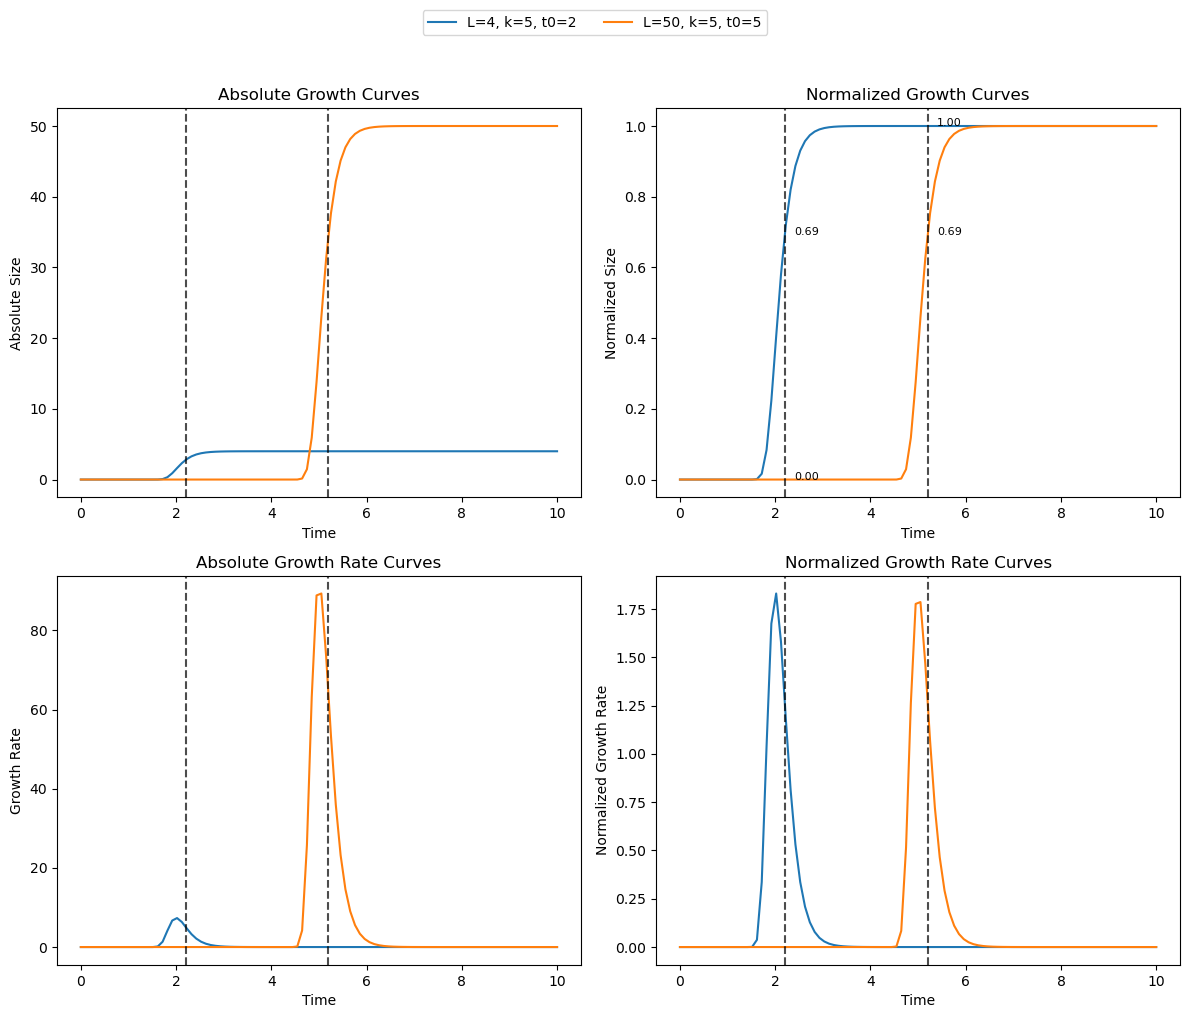

In [198]:
# Define parameters for the growth function
t_birth_values = [2.2,5.2]  # Different birth times
L_k_t0_combinations = [(4, 5, 2), (50, 5, 5)]  # Combinations of L, k, and t0

# Generate time points
t = np.linspace(0, 10, 100)

# Create a figure with 4 subplots
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

# Plot the absolute growth curves (left column, top)
for L, k, t0 in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = normalized_growth(t, k, t0, L)
    ax[0, 0].plot(t, y, label=f'L={L}, k={k}, t0={t0}')

# Add vertical lines for different birth times (absolute growth curves)
for t_birth in t_birth_values:
    ax[0, 0].axvline(x=t_birth, color='black', linestyle='--', alpha=0.7)

# Plot the absolute growth rate curves (left column, bottom)
for L, k, t0 in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = normalized_growth_rate(t, k, t0, L)
    ax[1, 0].plot(t, y, label=f'L={L}, k={k}, t0={t0}')

# Add vertical lines for different birth times (absolute growth rate curves)
for t_birth in t_birth_values:
    ax[1, 0].axvline(x=t_birth, color='black', linestyle='--', alpha=0.7)

# Plot the normalized growth curves (right column, top)
for L, k, t0 in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = normalized_growth(t, k, t0, L) / L  # Normalize by L
    ax[0, 1].plot(t, y, label=f'L={L}, k={k}, t0={t0}')
    # Add text where the vertical line intersects the curve
    for t_birth in t_birth_values:
        y_at_birth = normalized_growth(t_birth, k, t0, L) / L
        ax[0, 1].text(t_birth + 0.2, y_at_birth, f'{y_at_birth:.2f}', color='black', fontsize=8)

# Add vertical lines for different birth times (normalized growth curves)
for t_birth in t_birth_values:
    ax[0, 1].axvline(x=t_birth, color='black', linestyle='--', alpha=0.7)

# Plot the normalized growth rate curves (right column, bottom)
for L, k, t0 in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = normalized_growth_rate(t, k, t0, L) / L  # Normalize by L
    ax[1, 1].plot(t, y, label=f'L={L}, k={k}, t0={t0}')

# Add vertical lines for different birth times (normalized growth rate curves)
for t_birth in t_birth_values:
    ax[1, 1].axvline(x=t_birth, color='black', linestyle='--', alpha=0.7)

# Set titles and labels
ax[0, 0].set_title('Absolute Growth Curves')
ax[0, 0].set_xlabel('Time')
ax[0, 0].set_ylabel('Absolute Size')

ax[1, 0].set_title('Absolute Growth Rate Curves')
ax[1, 0].set_xlabel('Time')
ax[1, 0].set_ylabel('Growth Rate')

ax[0, 1].set_title('Normalized Growth Curves')
ax[0, 1].set_xlabel('Time')
ax[0, 1].set_ylabel('Normalized Size')

ax[1, 1].set_title('Normalized Growth Rate Curves')
ax[1, 1].set_xlabel('Time')
ax[1, 1].set_ylabel('Normalized Growth Rate')

# Add a single legend for the entire figure
handles, labels = ax[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the legend

# Compare "real" values

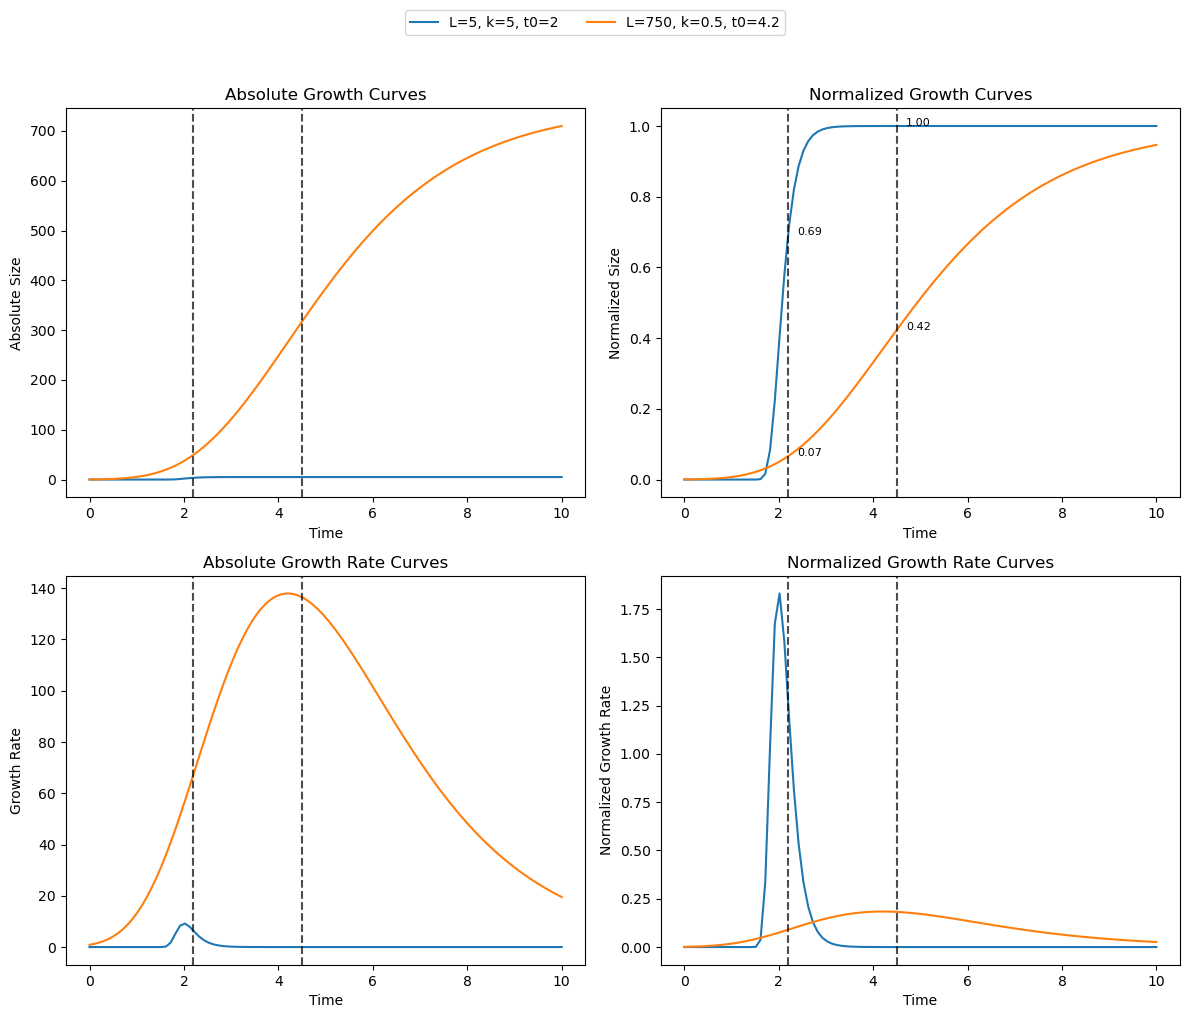

In [199]:
# Define parameters for the growth function
t_birth_values = [2.2,4.5]  # Different birth times
L_k_t0_combinations = [(5, 5, 2), (750, 0.5, 4.2)]  # Combinations of L, k, and t0

# Generate time points
t = np.linspace(0, 10, 100)

# Create a figure with 4 subplots
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

# Plot the absolute growth curves (left column, top)
for L, k, t0 in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = normalized_growth(t, k, t0, L)
    ax[0, 0].plot(t, y, label=f'L={L}, k={k}, t0={t0}')

# Add vertical lines for different birth times (absolute growth curves)
for t_birth in t_birth_values:
    ax[0, 0].axvline(x=t_birth, color='black', linestyle='--', alpha=0.7)

# Plot the absolute growth rate curves (left column, bottom)
for L, k, t0 in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = normalized_growth_rate(t, k, t0, L)
    ax[1, 0].plot(t, y, label=f'L={L}, k={k}, t0={t0}')

# Add vertical lines for different birth times (absolute growth rate curves)
for t_birth in t_birth_values:
    ax[1, 0].axvline(x=t_birth, color='black', linestyle='--', alpha=0.7)

# Plot the normalized growth curves (right column, top)
for L, k, t0 in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = normalized_growth(t, k, t0, L) / L  # Normalize by L
    ax[0, 1].plot(t, y, label=f'L={L}, k={k}, t0={t0}')
    # Add text where the vertical line intersects the curve
    for t_birth in t_birth_values:
        y_at_birth = normalized_growth(t_birth, k, t0, L) / L
        ax[0, 1].text(t_birth + 0.2, y_at_birth, f'{y_at_birth:.2f}', color='black', fontsize=8)

# Add vertical lines for different birth times (normalized growth curves)
for t_birth in t_birth_values:
    ax[0, 1].axvline(x=t_birth, color='black', linestyle='--', alpha=0.7)

# Plot the normalized growth rate curves (right column, bottom)
for L, k, t0 in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = normalized_growth_rate(t, k, t0, L) / L  # Normalize by L
    ax[1, 1].plot(t, y, label=f'L={L}, k={k}, t0={t0}')

# Add vertical lines for different birth times (normalized growth rate curves)
for t_birth in t_birth_values:
    ax[1, 1].axvline(x=t_birth, color='black', linestyle='--', alpha=0.7)

# Set titles and labels
ax[0, 0].set_title('Absolute Growth Curves')
ax[0, 0].set_xlabel('Time')
ax[0, 0].set_ylabel('Absolute Size')

ax[1, 0].set_title('Absolute Growth Rate Curves')
ax[1, 0].set_xlabel('Time')
ax[1, 0].set_ylabel('Growth Rate')

ax[0, 1].set_title('Normalized Growth Curves')
ax[0, 1].set_xlabel('Time')
ax[0, 1].set_ylabel('Normalized Size')

ax[1, 1].set_title('Normalized Growth Rate Curves')
ax[1, 1].set_xlabel('Time')
ax[1, 1].set_ylabel('Normalized Growth Rate')

# Add a single legend for the entire figure
handles, labels = ax[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the legend